### <b>library

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt

import timm

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

device: cpu


### <b>split, augmentasi, load

In [4]:
BATCH_SIZE = 16  
EPOCHS = 15      
LEARNING_RATE = 1e-3
IMG_SIZE = 300   

In [8]:
# path
TRAIN_PATH = '../data/cropped'

# transform
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# set dataset
full_dataset = datasets.ImageFolder(
    root=TRAIN_PATH,
    transform=val_transform  # default val dulu
)

class_names = full_dataset.classes

# split 80:20
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# dataloader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=2)

print(f"Data --> Train: {len(train_dataset)}, Val: {len(val_dataset)}")

Data --> Train: 1176, Val: 295


### <b>model

In [25]:
classes = ['realperson', 'fake_mask', 'fake_printed', 'fake_screen', 'fake_mannequin', 'fake_unknown']

In [26]:
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=len(classes), drop_rate=0.3)
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler()

In [27]:
train_losses, val_losses, val_accuracies = [], [], []
best_val_acc = 0.0

patience = 3 
patience_counter = 0

model_dir = '../Models/' 
os.makedirs(model_dir, exist_ok=True)

model_save_path = os.path.join(model_dir, 'efficientnet_b3_model.pth')

print("Training...")
for epoch in range(EPOCHS):
    
    model.train()
    running_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs.size(0)
        
        current_lr = scheduler.get_last_lr()[0]
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{current_lr:.6f}"})
        
    scheduler.step()
    
    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_dataset)
    epoch_val_acc = correct / total
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        
        torch.save(model.state_dict(), model_save_path)
        
        print(f"Model terbaik baru disimpan di {model_save_path}! (Akurasi: {best_val_acc:.4f})")
        patience_counter = 0 
    else:
        patience_counter += 1
        print(f"Tidak ada perbaikan. Early stopping counter: {patience_counter}/{patience}")
        
    if patience_counter >= patience:
        print(f"\nEarly Stopping diaktifkan! Proses training dihentikan pada Epoch {epoch+1} untuk mencegah overfitting.")
        break

print(f"\nTraining Selesai! Model paling stabil memiliki akurasi: {best_val_acc:.4f}")

Training...


Epoch 1/15 [Val]: 100%|██████████| 19/19 [00:19<00:00,  1.02s/it]


Epoch 1 | Train Loss: 1.4458 | Val Loss: 0.5632 | Val Acc: 0.8102
Model terbaik baru disimpan di ../Models/efficientnet_b3_model.pth! (Akurasi: 0.8102)


Epoch 2/15 [Val]: 100%|██████████| 19/19 [00:19<00:00,  1.04s/it]


Epoch 2 | Train Loss: 0.3037 | Val Loss: 0.6723 | Val Acc: 0.8610
Model terbaik baru disimpan di ../Models/efficientnet_b3_model.pth! (Akurasi: 0.8610)


...

Epoch 3 | Train Loss: 0.2771 | Val Loss: 0.6384 | Val Acc: 0.8102
Tidak ada perbaikan. Early stopping counter: 1/3


Epoch 4/15 [Val]: 100%|██████████| 19/19 [00:21<00:00,  1.12s/it]


Epoch 4 | Train Loss: 0.2830 | Val Loss: 0.8258 | Val Acc: 0.8000
Tidak ada perbaikan. Early stopping counter: 2/3


Epoch 5/15 [Val]: 100%|██████████| 19/19 [00:19<00:00,  1.02s/it]

Epoch 5 | Train Loss: 0.2177 | Val Loss: 0.7496 | Val Acc: 0.8305
Tidak ada perbaikan. Early stopping counter: 3/3

Early Stopping diaktifkan! Proses training dihentikan pada Epoch 5 untuk mencegah overfitting.

Training Selesai! Model paling stabil memiliki akurasi: 0.8610


In [30]:
import torch
import timm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('efficientnet_b3', pretrained=False, num_classes=6)
model.load_state_dict(torch.load('../Models/efficientnet_b3_model.pth', map_location=device))
model.to(device)
model.eval()

EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [31]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((300, 300)),  # efficientnet_b3 default
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [32]:
import os
from PIL import Image

TEST_PATH = '../data/test'

image_files = sorted([
    f for f in os.listdir(TEST_PATH)
    if f.endswith(('.jpg', '.png', '.jpeg'))
])

In [42]:
import pandas as pd

model_idx_to_class = {v:k for k,v in full_dataset.class_to_idx.items()}

class_to_label = {
    'realperson': 0,
    'fake_printed': 1,
    'fake_screen': 2,
    'fake_mask': 3,
    'fake_mannequin': 4,
    'fake_unknown': 5
}

results = []

for img_name in image_files:
    img_path = os.path.join(TEST_PATH, img_name)
    
    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    results.append([img_name, pred])

In [46]:
pred = torch.argmax(probs, dim=1).item()
results.append([img_name, pred])

In [47]:
df_sub = pd.DataFrame(results, columns=['image', 'label'])
df_sub.to_csv('../data/submission.csv', index=False)

print("Submission saved!")

Submission saved!


In [49]:
print(full_dataset.class_to_idx)

{'fake_mannequin': 0, 'fake_mask': 1, 'fake_printed': 2, 'fake_screen': 3, 'fake_unknown': 4, 'realperson': 5}


In [53]:
pd.read_csv("../data/submission.csv")


,image,label
0,test_001.jpg,3
1,test_002.jpg,0
2,test_003.jpg,1
3,test_004.jpg,5
4,test_005.jpg,3
...,...,...
400,test_401.jpg,1
401,test_402.jpg,3
402,test_403.jpeg,4
403,test_404.jpg,0


In [55]:
xx = pd.read_csv("../data/submission.csv")
xx

,image,label
0,test_001.jpg,3
1,test_002.jpg,0
2,test_003.jpg,1
3,test_004.jpg,5
4,test_005.jpg,3
...,...,...
400,test_401.jpg,1
401,test_402.jpg,3
402,test_403.jpeg,4
403,test_404.jpg,0


In [56]:
import pandas as pd

# load csv
xx = pd.read_csv("../data/submission.csv")

# mapping angka → label
label_map = {
    0: 'fake_mannequin',
    1: 'fake_mask',
    2: 'fake_printed',
    3: 'fake_screen',
    4: 'fake_unknown',
    5: 'realperson'
}

# convert angka ke label
xx['label'] = xx['label'].map(label_map)

# save
xx.to_csv("submission_label.csv", index=False)

# kalau mau tanpa header:
# xx.to_csv("submission_label.csv", index=False, header=False)

In [35]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
print(classification_report(y_true, y_pred, target_names=class_names))

                precision    recall  f1-score   support

fake_mannequin       0.92      0.86      0.89        42
     fake_mask       0.79      0.94      0.86        51
  fake_printed       0.71      0.68      0.70        22
   fake_screen       0.76      0.86      0.81        36
  fake_unknown       0.93      0.89      0.91        57
    realperson       0.94      0.84      0.88        87

      accuracy                           0.86       295
     macro avg       0.84      0.85      0.84       295
  weighted avg       0.87      0.86      0.86       295



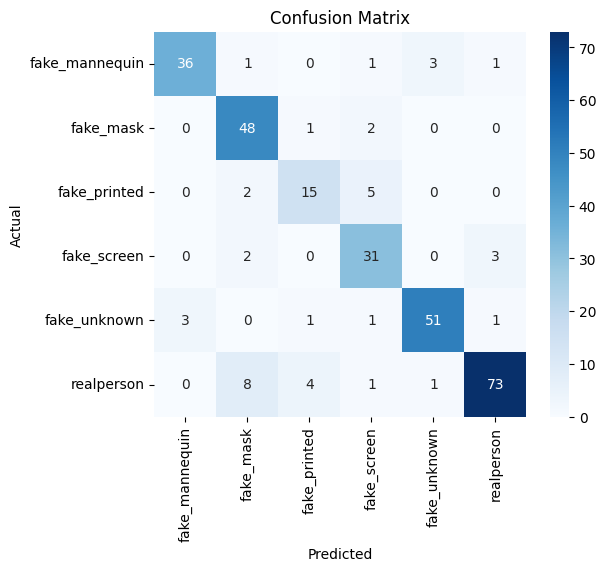

In [40]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()